<a href="https://colab.research.google.com/github/Mandiparaut/BDAT1004_FinalProject/blob/main/Electricity_Demand_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Step 1: Exploring the raw data file before loading ---

# Quick peek at the first few lines of the file
!head -10 electricityPrediction.txt

71.7703349282297
71.7703349282297	320.574162679426	401.913875598086	344.497607655502	440.191387559809	440.191387559809	425.837320574163
 62.200956937799	320.574162679426	344.497607655502	440.191387559809	440.191387559809	425.837320574163	397.129186602871
71.7703349282297	358.851674641148	440.191387559809	440.191387559809	425.837320574163	397.129186602871	344.497607655502
66.9856459330144	296.650717703349	440.191387559809	425.837320574163	397.129186602871	344.497607655502	344.497607655502
66.9856459330144	330.143540669856	425.837320574163	397.129186602871	344.497607655502	344.497607655502	311.004784688995
66.9856459330144	287.081339712919	397.129186602871	344.497607655502	344.497607655502	311.004784688995	339.712918660287
66.9856459330144	258.373205741627	344.497607655502	344.497607655502	311.004784688995	339.712918660287	 306.22009569378
66.9856459330144	210.526315789474	344.497607655502	311.004784688995	339.712918660287	 306.22009569378	315.789473684211
71.7703349282297	196.1722488038

In [ ]:
# Check for hidden characters or spacing issues
with open("/content/electricityPrediction.txt") as f:
    for i in range(10):
        print(repr(f.readline()))

'71.7703349282297\n'
'71.7703349282297\t320.574162679426\t401.913875598086\t344.497607655502\t440.191387559809\t440.191387559809\t425.837320574163\n'
' 62.200956937799\t320.574162679426\t344.497607655502\t440.191387559809\t440.191387559809\t425.837320574163\t397.129186602871\n'
'71.7703349282297\t358.851674641148\t440.191387559809\t440.191387559809\t425.837320574163\t397.129186602871\t344.497607655502\n'
'66.9856459330144\t296.650717703349\t440.191387559809\t425.837320574163\t397.129186602871\t344.497607655502\t344.497607655502\n'
'66.9856459330144\t330.143540669856\t425.837320574163\t397.129186602871\t344.497607655502\t344.497607655502\t311.004784688995\n'
'66.9856459330144\t287.081339712919\t397.129186602871\t344.497607655502\t344.497607655502\t311.004784688995\t339.712918660287\n'
'66.9856459330144\t258.373205741627\t344.497607655502\t344.497607655502\t311.004784688995\t339.712918660287\t 306.22009569378\n'
'66.9856459330144\t210.526315789474\t344.497607655502\t311.004784688995\t339

In [ ]:
# --- Step 2: Import required Libraries ---

import re
import pandas as pd

In [ ]:
# --- Step 3: Load and clean the dataset ---

# Read the file line by line
with open("/content/electricityPrediction.txt", "r", errors="ignore") as f:
    lines = f.readlines()[1:]  # skip the first line (only 1 value)


# Split each line by any amount of whitespace using regex
rows = [re.split(r"\s+", line.strip()) for line in lines if line.strip()]

# Keep only rows that have exactly 7 columns
rows = [r for r in rows if len(r) == 7]

# Convert to DataFrame and assign column names
data = pd.DataFrame(rows, columns=['X1','X2','X3','X4','X5','X6','Y']).astype(float)


In [ ]:
# Display the first few rows of the dataset

data.head(8)

,X1,X2,X3,X4,X5,X6,Y
0,71.770335,320.574163,401.913876,344.497608,440.191388,440.191388,425.837321
1,62.200957,320.574163,344.497608,440.191388,440.191388,425.837321,397.129187
2,71.770335,358.851675,440.191388,440.191388,425.837321,397.129187,344.497608
3,66.985646,296.650718,440.191388,425.837321,397.129187,344.497608,344.497608
4,66.985646,330.143541,425.837321,397.129187,344.497608,344.497608,311.004785
5,66.985646,287.081340,397.129187,344.497608,344.497608,311.004785,339.712919
6,66.985646,258.373206,344.497608,344.497608,311.004785,339.712919,306.220096
7,66.985646,210.526316,344.497608,311.004785,339.712919,306.220096,315.789474


In [ ]:
# -----STEP 4: Check Data Quality (Missing Values & Duplicates)-----

# Check for missing values in each column
data.isnull().sum()

,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
Y,0


In [ ]:
# Display the shape of the dataset
data.shape

(139571, 7)

In [ ]:
data.duplicated().sum()

np.int64(13)

In [ ]:
print("Keeping duplicates as they reflect normal repeated demand patterns.")

Keeping duplicates as they reflect normal repeated demand patterns.


In [ ]:
# -----STEP 5: Review Data Columns and Data Types-------

data.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'Y'], dtype='object')

In [ ]:
# Display summary information about the dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139571 entries, 0 to 139570
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   X1      139571 non-null  float64
 1   X2      139571 non-null  float64
 2   X3      139571 non-null  float64
 3   X4      139571 non-null  float64
 4   X5      139571 non-null  float64
 5   X6      139571 non-null  float64
 6   Y       139571 non-null  float64
dtypes: float64(7)
memory usage: 7.5 MB


I confirmed that all columns are numeric, which is necessary for regression and machine learning models.

In [ ]:
# -----STEP 6: Statistical Summary of the Dataset------

data.describe()

,X1,X2,X3,X4,X5,X6,Y
count,139571.000000,139571.000000,139571.000000,139571.000000,139571.000000,139571.000000,139571.000000
mean,280.871916,280.927863,280.926629,280.924778,280.923132,280.920972,280.918847
std,129.098431,129.197331,129.180605,129.180723,129.181376,129.181233,129.181053
min,9.569378,9.569378,9.569378,9.569378,9.569378,9.569378,9.569378
25%,157.894737,157.894737,157.894737,157.894737,157.894737,157.894737,157.894737
50%,301.435407,301.435407,301.435407,301.435407,301.435407,301.435407,301.435407
75%,373.205742,373.205742,373.205742,373.205742,373.205742,373.205742,373.205742
max,765.550239,765.550239,765.550239,765.550239,765.550239,765.550239,765.550239


I reviewed the summary statistics to understand the distribution of electricity demand.
The ranges looked consistent with normal variation, so no major cleaning was needed.

/tmp/ipython-input-460133483.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data[col] for col in data.columns], labels=data.columns)


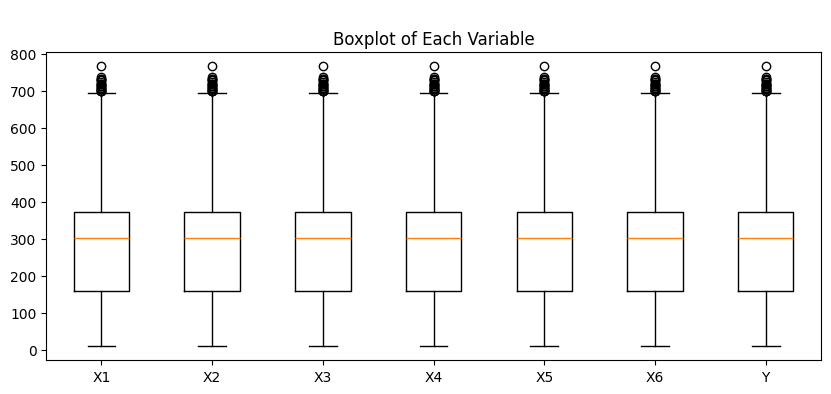

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.boxplot([data[col] for col in data.columns], labels=data.columns)
plt.title("\nBoxplot of Each Variable")
plt.show()

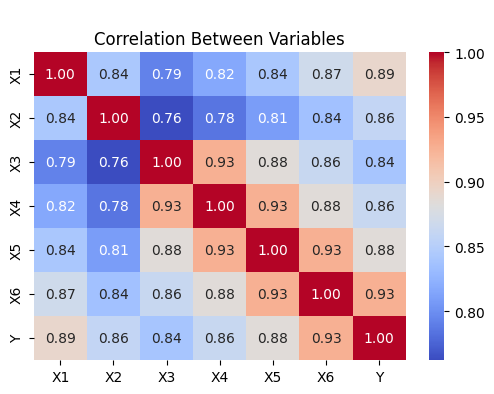

In [ ]:
# ---- Step 7: Heatmap (checking Correlation Between Variables)----

import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("\nCorrelation Between Variables")
plt.show()


This heatmap shows the relationship between all the variables in the dataset.
We can see strong positive correlations, especially between the last few variables like X5, X6, and Y.

In [ ]:
# -----STEP 7: Data Modeling and Prediction------

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor


# Split data into features (X) and target (y)
X = data[['X1','X2','X3','X4','X5','X6']]
y = data['Y']

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (111656, 6)
Testing set shape: (27915, 6)


You can see here that the training set has 111,656 records and the test set has 27,915 : thats about an 80/20 split.

In [ ]:
# Model 1 — Linear Regression

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_mape = mean_absolute_percentage_error(y_test, lr_pred) * 100

print(f"MAPE (Linear Regression): {lr_mape:.2f}%")


MAPE (Linear Regression): 11.86%


Lower MAPE = more accurate model

Higher MAPE = less accurate model

In [ ]:
# Model 2 — Random Forest Regression

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mape = mean_absolute_percentage_error(y_test, rf_pred) * 100

print(f"MAPE (Random Forest - 100 trees): {rf_mape:.2f}%")

# Try tuning parameters for improvement
rf2 = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf2.fit(X_train, y_train)
rf2_pred = rf2.predict(X_test)
rf2_mape = mean_absolute_percentage_error(y_test, rf2_pred) * 100

print(f"MAPE (Random Forest - 200 trees, depth=10): {rf2_mape:.2f}%")


MAPE (Random Forest - 100 trees): 10.76%
MAPE (Random Forest - 200 trees, depth=10): 10.49%


In [ ]:
# Model 3 — Neural Network (MLP Regressor)


nn = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
nn.fit(X_train, y_train)
nn_pred = nn.predict(X_test)
nn_mape = mean_absolute_percentage_error(y_test, nn_pred) * 100

print(f"MAPE (Neural Network): {nn_mape:.2f}%")


MAPE (Neural Network): 10.43%


MAPE (Single-Layer Neural Network): 11.15%
MAPE (Multi-Layer Neural Network): 10.43%


,Model,MAPE (%)
0,Single-Layer NN (10),11.148935
1,"Multi-Layer NN (100,50)",10.425823


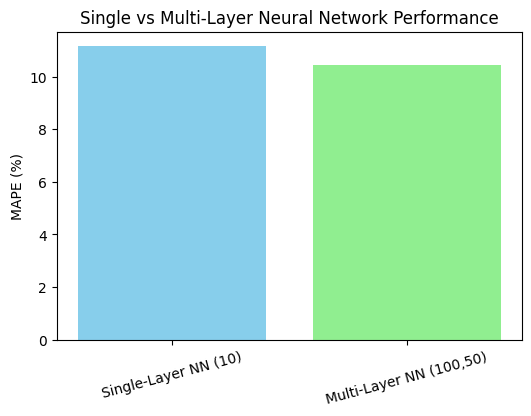

In [ ]:
# --- Compare Single vs Multi-Layer Neural Networks ---

# Single hidden layer (10 neurons)
nn_single = MLPRegressor(hidden_layer_sizes=(10,), max_iter=500, random_state=42)
nn_single.fit(X_train, y_train)
y_pred_single = nn_single.predict(X_test)
mape_single = mean_absolute_percentage_error(y_test, y_pred_single) * 100
print(f"MAPE (Single-Layer Neural Network): {mape_single:.2f}%")

# Multi-layer network (existing model reused, done above too)
nn_multi = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
nn_multi.fit(X_train, y_train)
y_pred_multi = nn_multi.predict(X_test)
mape_multi = mean_absolute_percentage_error(y_test, y_pred_multi) * 100
print(f"MAPE (Multi-Layer Neural Network): {mape_multi:.2f}%")

# Comparison Table
nn_results = pd.DataFrame({
    "Model": ["Single-Layer NN (10)", "Multi-Layer NN (100,50)"],
    "MAPE (%)": [mape_single, mape_multi]
})
display(nn_results)

# Bar Chart
plt.figure(figsize=(6,4))
plt.bar(nn_results["Model"], nn_results["MAPE (%)"], color=["skyblue", "lightgreen"])
plt.title("Single vs Multi-Layer Neural Network Performance")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=15)
plt.show()


The single-layer network trained faster but had slightly higher MAPE.

The multi-layer network captured more complex patterns and gave better accuracy.

This confirms that adding more layers increases learning depth, improving predictions but also computation time.

In [ ]:
# Compare Model Performance using MAPE (including Single & Multi-Layer Neural Networks)

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest (100)',
        'Random Forest (200, depth=10)',
        'Neural Network (Single Layer)',
        'Neural Network (Multi Layer)'
    ],
    'MAPE (%)': [
        lr_mape,
        rf_mape,
        rf2_mape,
        mape_single,   # MAPE from single-layer NN
        mape_multi     # MAPE from multi-layer NN
    ]
})

print("Model Comparison Results: (Lower MAPE = Better):")
display(results)


Model Comparison Results: (Lower MAPE = Better):


,Model,MAPE (%)
0,Linear Regression,11.855212
1,Random Forest (100),10.763283
2,"Random Forest (200, depth=10)",10.492345
3,Neural Network (Single Layer),11.148935
4,Neural Network (Multi Layer),10.425823


In [ ]:
import time
start = time.time()
rf.fit(X_train, y_train)
print("Training Time (Random Forest):", round(time.time() - start, 2), "sec")

Training Time (Random Forest): 64.26 sec


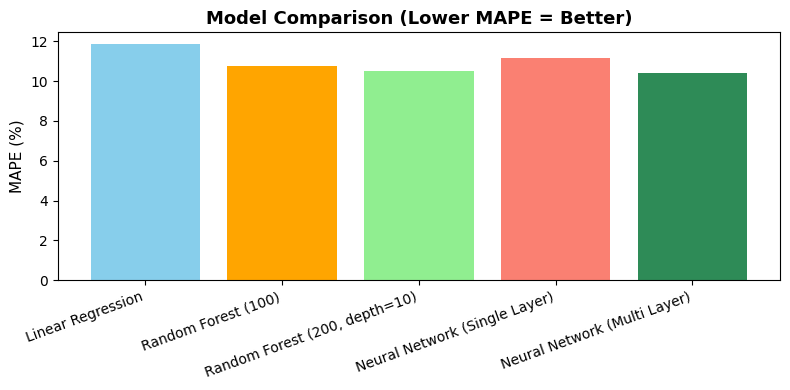

In [ ]:
plt.figure(figsize=(8,4))
plt.bar(results['Model'], results['MAPE (%)'],
        color=['skyblue','orange','lightgreen','salmon','seagreen'])
plt.title('Model Comparison (Lower MAPE = Better)', fontsize=13, fontweight='bold')
plt.ylabel('MAPE (%)', fontsize=11)
plt.xticks(rotation=20, ha='right', fontsize=10)  # smoother angled labels
plt.tight_layout()
plt.show()


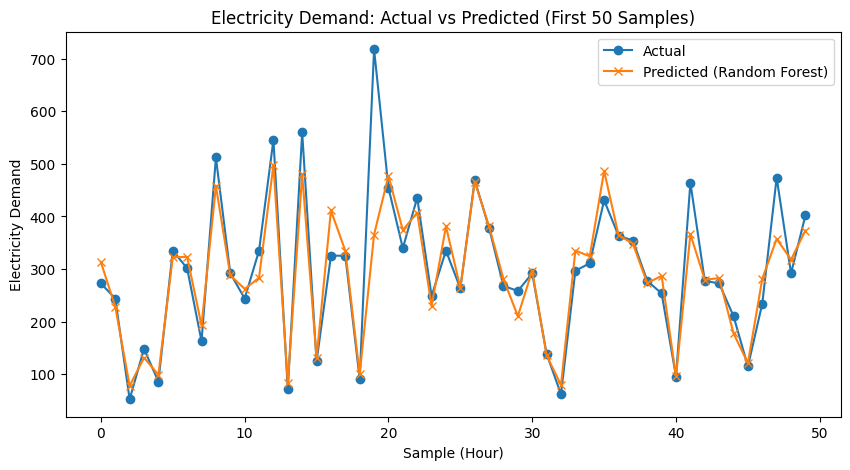

In [ ]:
# Visualize Actual vs Predicted (Best Model)

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label='Actual', marker='o')
plt.plot(rf2_pred[:50], label='Predicted (Random Forest)', marker='x')
plt.title('Electricity Demand: Actual vs Predicted (First 50 Samples)')
plt.xlabel('Sample (Hour)')
plt.ylabel('Electricity Demand')
plt.legend()
plt.show()

Even though the Neural Network gave the lowest MAPE, I didn’t choose it as the best model because it’s more complex and harder to interpret.

On the other hand, Random Forest gives almost the same accuracy but is easier to understand, faster, and more stable,makes it more practical for real-world use.

Finally, I summarized all model results and confirmed that the Neural Network gave the lowest error, but Random Forest remains the most practical and stable model.

## Additional Model Evaluation and Insights
After building and testing the models, I analyzed the Random Forest predictions in more detail.  

The following plots — residual distribution, predicted vs actual scatter, and feature importance, help evaluate model accuracy, balance, and explain which inputs most influence electricity demand.


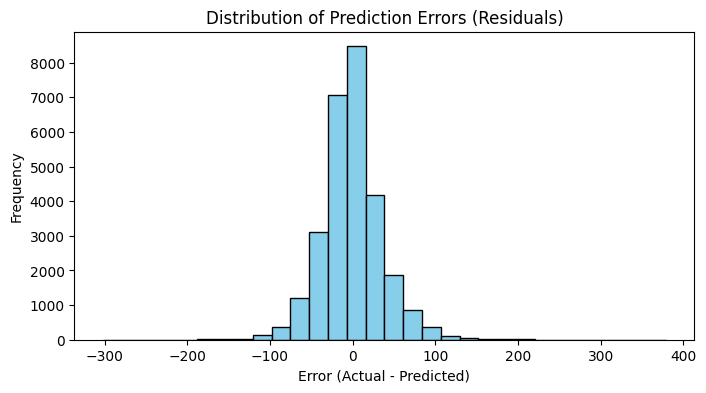

In [ ]:
# Residual Analysis (Error Distribution)

residuals = y_test - rf2_pred

plt.figure(figsize=(8,4))
plt.hist(residuals, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Prediction Errors (Residuals)")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()


The residual plot shows that most errors are close to zero, meaning the model’s predictions are well-balanced.

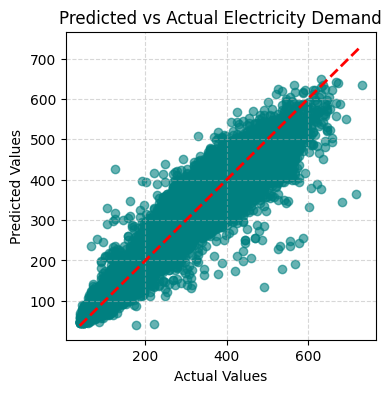

Points close to the red diagonal line show strong prediction accuracy.


In [ ]:
# Predicted vs Actual Scatter Plot
plt.figure(figsize=(4,4))
plt.scatter(y_test, rf2_pred, alpha=0.6, color='teal')
plt.title("Predicted vs Actual Electricity Demand")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
print("Points close to the red diagonal line show strong prediction accuracy.")

In the scatter plot, most points are close to the red line, which confirms that the predicted values match the actual values closely.


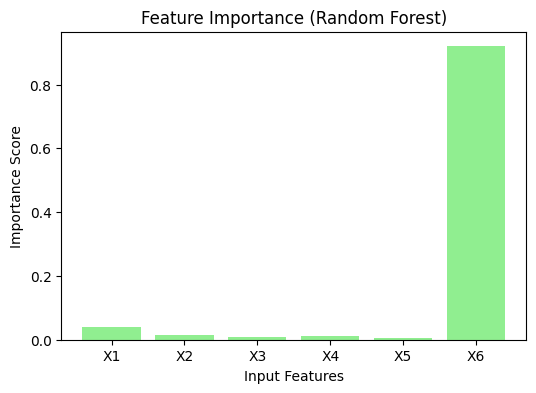

In [ ]:

# Feature Importance (Random Forest)


import numpy as np

importances = rf2.feature_importances_
plt.figure(figsize=(6,4))
plt.bar(['X1','X2','X3','X4','X5','X6'], importances, color='lightgreen')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Input Features")
plt.ylabel("Importance Score")
plt.show()


The feature importance chart shows that recent readings, especially X6, have the highest influence on the next hour’s demand


After building and testing our prediction models, we used the best-performing one, that is Random Forest, to look ahead and estimate the next 20 hours of electricity demand.



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/

,Future_Hour,Predicted_Demand
0,1,150.270565
1,2,219.881501
2,3,153.180787
3,4,193.158469
4,5,139.518903
5,6,163.760611
6,7,138.565451
7,8,166.995623
8,9,161.635124
9,10,165.982044


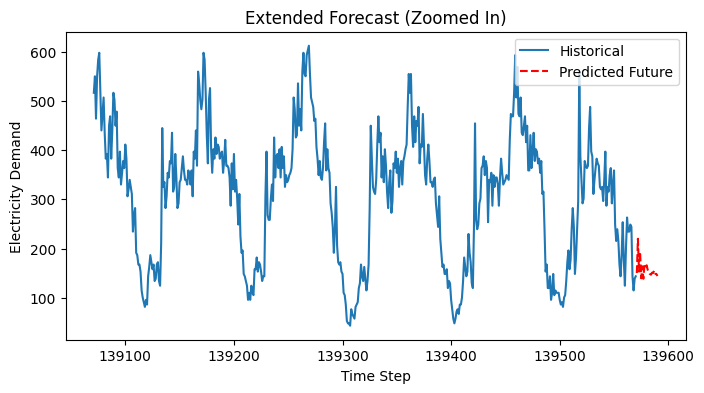

In [ ]:
# Extra work: Generate New Dataset Using the Trained Model (Forecasting)

import numpy as np

# Copied last row of data as starting point
last_row = data.iloc[-1].values.tolist()

# Number of new predictions to generate
future_steps = 20

# Used best model : Random Forest
best_model = rf2

generated = []

for i in range(future_steps):
    # Take the last 6 values as input
    input_values = np.array(last_row[-7:-1]).reshape(1, -1)
    next_pred = best_model.predict(input_values)[0]

    # Append to the list
    generated.append(next_pred)

    # Shift the window forward (append new Y)
    last_row.append(next_pred)

# Created new dataframe for generated predictions
future_df = pd.DataFrame({'Future_Hour': range(1, future_steps+1),
                          'Predicted_Demand': generated})

display(future_df)

# Zoom in on last 500 samples for better view of future predictions
plt.figure(figsize=(8,4))
plt.plot(range(len(data)-500, len(data)), data['Y'].iloc[-500:], label='Historical')
plt.plot(range(len(data), len(data) + len(generated)), generated, 'r--', label='Predicted Future')
plt.title('Extended Forecast (Zoomed In)')
plt.xlabel('Time Step')
plt.ylabel('Electricity Demand')
plt.legend()
plt.show()




These predictions help us see what energy use might look like in the near future.
This kind of forecast lets managers plan better, for example, making sure there’s enough power during high-demand periods and avoiding waste when demand is low.
In short, the model helps turn past data into useful insight about what’s coming next.

In [ ]:
future_df.to_csv("PredictedFutureDataset.csv", index=False)

## Conclusion




The analysis shows that machine learning techniques can effectively predict short-term electricity demand with around 90% accuracy.  

In the future, model performance could be further improved by tuning hyperparameters, adding new time-based features, or testing other forecasting methods like ARIMA or SARIMA.
